In [1]:
!pip install gymnasium minigrid stable-baselines3[extra] matplotlib numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.7/136.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 17.2 MB/s eta 0:00:00


In [14]:
import gymnasium as gym
from minigrid.wrappers import ImgObsWrapper
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import os

In [31]:

class CustomRewardWrapper(Wrapper):
    def __init__(self, env):
        super().__init__(env)
        self.prev_pos = None

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.prev_pos = tuple(self.env.unwrapped.agent_pos)
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        self.env.unwrapped.last_info = info
        self.env.unwrapped.done = terminated or truncated

        custom_reward = compute_reward(self.env, self.prev_pos)
        reward = custom_reward

        self.prev_pos = tuple(self.env.unwrapped.agent_pos)

        return obs, reward, terminated, truncated, info

In [32]:
env = gym.make("MiniGrid-Empty-8x8-v0", render_mode="rgb_array")
env = ImgObsWrapper(env)
env = CustomRewardWrapper(env)

In [33]:
from stable_baselines3 import PPO

model = PPO(
    "MlpPolicy",
    env,
    learning_rate=1e-4,
    gamma=0.995,
    n_steps=2048,
    batch_size=256,
    ent_coef=0.01,
    verbose=1,
    tensorboard_log="./ppo_minigrid_tb/"
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.


In [34]:
from stable_baselines3.common.callbacks import EvalCallback

eval_env = gym.make("MiniGrid-Empty-8x8-v0", render_mode="rgb_array")
eval_env = ImgObsWrapper(eval_env)
eval_env = CustomRewardWrapper(eval_env)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="./best_model",
    log_path="./logs",
    eval_freq=5000,
    deterministic=True
)

model.learn(
    total_timesteps=250000,
    callback=eval_callback
)

Logging to ./ppo_minigrid_tb/PPO_4


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7ec53d58aed0> != <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object at 0x7ec53d770470>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 239      |
|    ep_rew_mean     | -73.1    |
| time/              |          |
|    fps             | 902      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 236           |
|    ep_rew_mean          | -72.5         |
| time/                   |               |
|    fps                  | 839           |
|    iterations           | 2             |
|    time_elapsed         | 4             |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 1.2192177e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.95         |
|    explained_variance   | 0.000319      |


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Eval num_timesteps=5000, episode_reward=-83.00 +/- 0.00
Episode length: 256.00 +/- 0.00
------------------------------------------
| eval/                   |              |
|    mean_ep_length       | 256          |
|    mean_reward          | -83          |
| time/                   |              |
|    total_timesteps      | 5000         |
| train/                  |              |
|    approx_kl            | 7.735565e-06 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.95        |
|    explained_variance   | 0.00398      |
|    learning_rate        | 0.0001       |
|    loss                 | 12.7         |
|    n_updates            | 20           |
|    policy_gradient_loss | -0.000104    |
|    value_loss           | 27.3         |
------------------------------------------
New best mean reward!
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 243      |
|    ep_rew_me

In [35]:
model.save("ppo_minigrid_navigation")

In [36]:
model = PPO.load("ppo_minigrid_navigation")

obs, info = env.reset()
done = False

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    env.render()

In [37]:
from stable_baselines3.common.vec_env import DummyVecEnv, VecVideoRecorder

def make_env():
    env = gym.make("MiniGrid-Empty-8x8-v0", render_mode="rgb_array")
    env = ImgObsWrapper(env)
    env = CustomRewardWrapper(env)
    return env

vec_env = DummyVecEnv([make_env])

vec_env = VecVideoRecorder(
    vec_env,
    video_folder="videos/",
    record_video_trigger=lambda x: x == 0,
    video_length=200,
    name_prefix="minigrid"
)

obs = vec_env.reset()

for _ in range(200):
    action, _ = model.predict(obs, deterministic=True)
    obs, _, done, _ = vec_env.step(action)
    if done:
        break

vec_env.close()

Moviepy - Building video /content/videos/minigrid-step-0-to-step-200.mp4.
Moviepy - Writing video /content/videos/minigrid-step-0-to-step-200.mp4



Moviepy - Done !
Moviepy - video ready /content/videos/minigrid-step-0-to-step-200.mp4


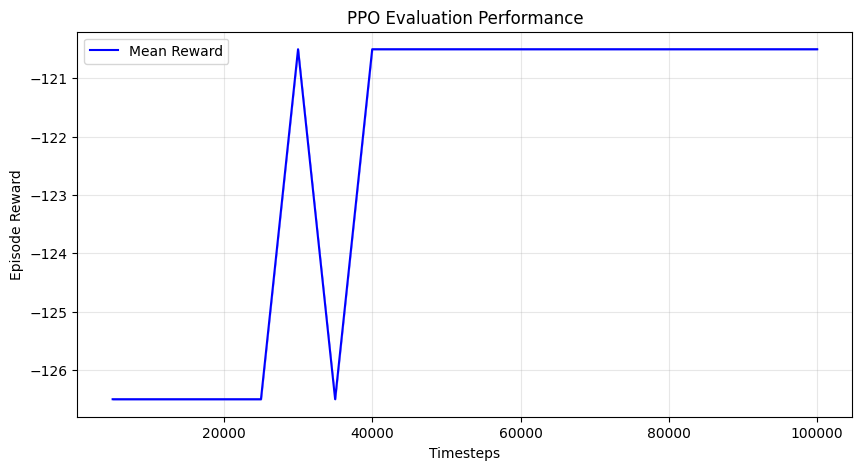

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import os

log_path = './logs/results/evaluations.npz'

if os.path.exists(log_path):
    data = np.load(log_path)

    timesteps = data["timesteps"]
    results = data["results"]  # shape: (n_evals, n_episodes)

    mean_rewards = results.mean(axis=1)
    min_rewards = results.min(axis=1)
    max_rewards = results.max(axis=1)

    plt.figure(figsize=(10, 5))

    plt.plot(timesteps, mean_rewards, label="Mean Reward", color="blue")
    plt.fill_between(
        timesteps,
        min_rewards,
        max_rewards,
        alpha=0.25,
        color="blue"
    )

    plt.xlabel("Timesteps")
    plt.ylabel("Episode Reward")
    plt.title("PPO Evaluation Performance")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

else:
    print("❌ evaluations.npz bulunamadı. EvalCallback doğru çalışmıyor olabilir.")

deney iki

In [39]:
model = PPO(
    "MlpPolicy",
    env,
    learning_rate=3e-4,
    gamma=0.995,
    n_steps=2048,
    batch_size=256,
    ent_coef=0.01,
    verbose=1,
    tensorboard_log="./ppo_minigrid_tb/"
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.


In [40]:
from stable_baselines3.common.callbacks import EvalCallback

eval_env = gym.make("MiniGrid-Empty-8x8-v0", render_mode="rgb_array")
eval_env = ImgObsWrapper(eval_env)
eval_env = CustomRewardWrapper(eval_env)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="./best_model",
    log_path="./logs",
    eval_freq=5000,
    deterministic=True
);

model.learn(
    total_timesteps=250000,
    callback=eval_callback
)

Logging to ./ppo_minigrid_tb/PPO_5


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7ec53d58d490> != <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object at 0x7ec53d593380>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 256      |
|    ep_rew_mean     | -80.1    |
| time/              |          |
|    fps             | 912      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 236           |
|    ep_rew_mean          | -73.5         |
| time/                   |               |
|    fps                  | 832           |
|    iterations           | 2             |
|    time_elapsed         | 4             |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00043971106 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.95         |
|    explained_variance   | -0.000501     |


In [41]:
model.save("ppo_minigrid_navigation")
model = PPO.load("ppo_minigrid_navigation")

obs, info = env.reset()
done = False

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    env.render()



from stable_baselines3.common.vec_env import DummyVecEnv, VecVideoRecorder

def make_env():
    env = gym.make("MiniGrid-Empty-8x8-v0", render_mode="rgb_array")
    env = ImgObsWrapper(env)
    env = CustomRewardWrapper(env)
    return env

vec_env = DummyVecEnv([make_env])

vec_env = VecVideoRecorder(
    vec_env,
    video_folder="videos/",
    record_video_trigger=lambda x: x == 0,
    video_length=200,
    name_prefix="minigrid"
)

obs = vec_env.reset()

for _ in range(200):
    action, _ = model.predict(obs, deterministic=True)
    obs, _, done, _ = vec_env.step(action)
    if done:
        break

vec_env.close()

Moviepy - Building video /content/videos/minigrid-step-0-to-step-200.mp4.
Moviepy - Writing video /content/videos/minigrid-step-0-to-step-200.mp4



Moviepy - Done !
Moviepy - video ready /content/videos/minigrid-step-0-to-step-200.mp4


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

log_path = './logs/results/evaluations.npz'

if os.path.exists(log_path):
    data = np.load(log_path)

    timesteps = data["timesteps"]
    results = data["results"]  # shape: (n_evals, n_episodes)

    mean_rewards = results.mean(axis=1)
    min_rewards = results.min(axis=1)
    max_rewards = results.max(axis=1)

    plt.figure(figsize=(10, 5))

    plt.plot(timesteps, mean_rewards, label="Mean Reward", color="blue")
    plt.fill_between(
        timesteps,
        min_rewards,
        max_rewards,
        alpha=0.25,
        color="blue"
    )

    plt.xlabel("Timesteps")
    plt.ylabel("Episode Reward")
    plt.title("PPO Evaluation Performance")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

else:
    print("❌ evaluations.npz bulunamadı. EvalCallback doğru çalışmıyor olabilir.")

deney üç

In [27]:
model = PPO(
    "MlpPolicy",
    env,
    learning_rate=3e-4,
    gamma=0.90,
    n_steps=2048,
    batch_size=256,
    ent_coef=0.01,
    verbose=1,
    tensorboard_log="./ppo_minigrid_tb/"
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.


In [28]:
from stable_baselines3.common.callbacks import EvalCallback

eval_env = gym.make("MiniGrid-Empty-8x8-v0", render_mode="rgb_array")
eval_env = ImgObsWrapper(eval_env)
eval_env = CustomRewardWrapper(eval_env)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="./best_model",
    log_path="./logs",
    eval_freq=5000,
    deterministic=True
);

model.learn(
    total_timesteps=250000,
    callback=eval_callback
)

Logging to ./ppo_minigrid_tb/PPO_3


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7ec53d74b740> != <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object at 0x7ec53d73d070>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 256      |
|    ep_rew_mean     | -79.3    |
| time/              |          |
|    fps             | 911      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 234         |
|    ep_rew_mean          | -73.3       |
| time/                   |             |
|    fps                  | 837         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.000492061 |
|    clip_fraction        | 0           |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.95       |
|    explained_variance   | -0.000534   |
|    learning_rate        | 0.

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Eval num_timesteps=5000, episode_reward=-83.00 +/- 0.00
Episode length: 256.00 +/- 0.00
-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 256         |
|    mean_reward          | -83         |
| time/                   |             |
|    total_timesteps      | 5000        |
| train/                  |             |
|    approx_kl            | 0.008970793 |
|    clip_fraction        | 0.0558      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.94       |
|    explained_variance   | -0.00383    |
|    learning_rate        | 0.0003      |
|    loss                 | 0.533       |
|    n_updates            | 20          |
|    policy_gradient_loss | -0.00627    |
|    value_loss           | 1.51        |
-----------------------------------------
New best mean reward!
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 235      |
|    ep_rew_mean     | -72.7    

In [29]:
model.save("ppo_minigrid_navigation")
model = PPO.load("ppo_minigrid_navigation")

obs, info = env.reset()
done = False

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    env.render()



from stable_baselines3.common.vec_env import DummyVecEnv, VecVideoRecorder

def make_env():
    env = gym.make("MiniGrid-Empty-8x8-v0", render_mode="rgb_array")
    env = ImgObsWrapper(env)
    env = CustomRewardWrapper(env)
    return env

vec_env = DummyVecEnv([make_env])

vec_env = VecVideoRecorder(
    vec_env,
    video_folder="videos/",
    record_video_trigger=lambda x: x == 0,
    video_length=200,
    name_prefix="minigrid"
)

obs = vec_env.reset()

for _ in range(200):
    action, _ = model.predict(obs, deterministic=True)
    obs, _, done, _ = vec_env.step(action)
    if done:
        break

vec_env.close()

Saving video to /content/videos/minigrid-step-0-to-step-200.mp4
Moviepy - Building video /content/videos/minigrid-step-0-to-step-200.mp4.
Moviepy - Writing video /content/videos/minigrid-step-0-to-step-200.mp4



Moviepy - Done !
Moviepy - video ready /content/videos/minigrid-step-0-to-step-200.mp4


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

log_path = './logs/results/evaluations.npz'

if os.path.exists(log_path):
    data = np.load(log_path)

    timesteps = data["timesteps"]
    results = data["results"]  # shape: (n_evals, n_episodes)

    mean_rewards = results.mean(axis=1)
    min_rewards = results.min(axis=1)
    max_rewards = results.max(axis=1)

    plt.figure(figsize=(10, 5))

    plt.plot(timesteps, mean_rewards, label="Mean Reward", color="blue")
    plt.fill_between(
        timesteps,
        min_rewards,
        max_rewards,
        alpha=0.25,
        color="blue"
    )

    plt.xlabel("Timesteps")
    plt.ylabel("Episode Reward")
    plt.title("PPO Evaluation Performance")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

else:
    print("❌ evaluations.npz bulunamadı. EvalCallback doğru çalışmıyor olabilir.")

deney dört




In [44]:
model = PPO(
    "MlpPolicy",
    env,
    learning_rate=1e-4,
    gamma=0.95,
    n_steps=2048,
    batch_size=256,
    ent_coef=0.01,
    verbose=1,
    tensorboard_log="./ppo_minigrid_tb/"
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.


In [45]:
from stable_baselines3.common.callbacks import EvalCallback

eval_env = gym.make("MiniGrid-Empty-8x8-v0", render_mode="rgb_array")
eval_env = ImgObsWrapper(eval_env)
eval_env = CustomRewardWrapper(eval_env)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="./best_model",
    log_path="./logs",
    eval_freq=5000,
    deterministic=True
);

model.learn(
    total_timesteps=250000,
    callback=eval_callback
)

Logging to ./ppo_minigrid_tb/PPO_6


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7ec53d74aab0> != <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object at 0x7ec53d58f110>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 226      |
|    ep_rew_mean     | -70.6    |
| time/              |          |
|    fps             | 913      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 240           |
|    ep_rew_mean          | -74.3         |
| time/                   |               |
|    fps                  | 766           |
|    iterations           | 2             |
|    time_elapsed         | 5             |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 3.9204897e-06 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.95         |
|    explained_variance   | -0.000852     |


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Eval num_timesteps=5000, episode_reward=-83.00 +/- 0.00
Episode length: 256.00 +/- 0.00
------------------------------------------
| eval/                   |              |
|    mean_ep_length       | 256          |
|    mean_reward          | -83          |
| time/                   |              |
|    total_timesteps      | 5000         |
| train/                  |              |
|    approx_kl            | 1.681535e-05 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.95        |
|    explained_variance   | -0.000888    |
|    learning_rate        | 0.0001       |
|    loss                 | 3.83         |
|    n_updates            | 20           |
|    policy_gradient_loss | -0.000224    |
|    value_loss           | 8.78         |
------------------------------------------
New best mean reward!
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 245      |
|    ep_rew_me

In [46]:
model.save("ppo_minigrid_navigation")
model = PPO.load("ppo_minigrid_navigation")

obs, info = env.reset()
done = False

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    env.render()



from stable_baselines3.common.vec_env import DummyVecEnv, VecVideoRecorder

def make_env():
    env = gym.make("MiniGrid-Empty-8x8-v0", render_mode="rgb_array")
    env = ImgObsWrapper(env)
    env = CustomRewardWrapper(env)
    return env

vec_env = DummyVecEnv([make_env])

vec_env = VecVideoRecorder(
    vec_env,
    video_folder="videos/",
    record_video_trigger=lambda x: x == 0,
    video_length=200,
    name_prefix="minigrid"
)

obs = vec_env.reset()

for _ in range(200):
    action, _ = model.predict(obs, deterministic=True)
    obs, _, done, _ = vec_env.step(action)
    if done:
        break

vec_env.close()

Saving video to /content/videos/minigrid-step-0-to-step-200.mp4
Moviepy - Building video /content/videos/minigrid-step-0-to-step-200.mp4.
Moviepy - Writing video /content/videos/minigrid-step-0-to-step-200.mp4



Moviepy - Done !
Moviepy - video ready /content/videos/minigrid-step-0-to-step-200.mp4


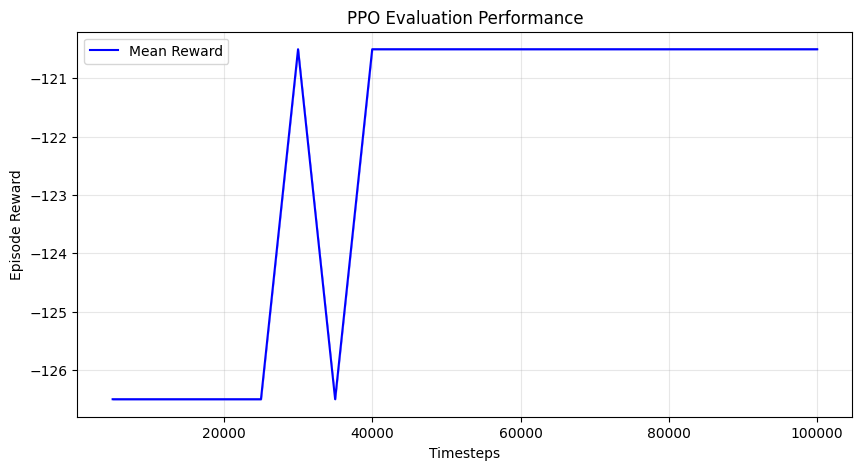

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import os

log_path = './logs/results/evaluations.npz'

if os.path.exists(log_path):
    data = np.load(log_path)

    timesteps = data["timesteps"]
    results = data["results"]  # shape: (n_evals, n_episodes)

    mean_rewards = results.mean(axis=1)
    min_rewards = results.min(axis=1)
    max_rewards = results.max(axis=1)

    plt.figure(figsize=(10, 5))

    plt.plot(timesteps, mean_rewards, label="Mean Reward", color="blue")
    plt.fill_between(
        timesteps,
        min_rewards,
        max_rewards,
        alpha=0.25,
        color="blue"
    )

    plt.xlabel("Timesteps")
    plt.ylabel("Episode Reward")
    plt.title("PPO Evaluation Performance")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

else:
    print("❌ evaluations.npz bulunamadı. EvalCallback doğru çalışmıyor olabilir.")